## Comparison of NNLS and NPLS

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import matplotlib.pyplot as plt
from scipy import stats

#### Loading Evaluation of NNLS and L2reg Global Models

In [2]:
methods = ['NNLS', 'NPLS']
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets
eval_ds_names = [ds if gl.sessions[i] == 'all' else ds + gl.sessions[i].split('-')[1] for i, ds in enumerate(gl.datasets)]
df_all = pd.DataFrame()
for i, (ds_code, ds_eval) in enumerate(zip(train_ds_list, eval_ds_names)):
    df = rm.comb_eval(models=[ds_code+"-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_all = pd.concat([df_all, df], ignore_index=True)
df_all['logalpha'] = df_all['logalpha'].fillna(-4)
df_all.model = 'Global'

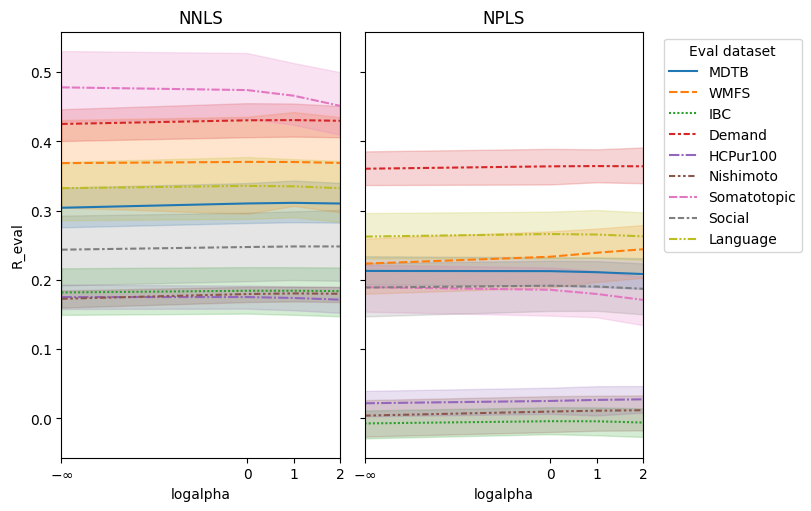

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey='row', constrained_layout=True)
for i, method in enumerate(methods):
    sns.lineplot(data=df_all[df_all['method']==method], y='R_eval', x='logalpha',
                hue='eval_dataset', style='eval_dataset',
                hue_order=eval_ds_list, style_order=eval_ds_list, ax=axes[i])
    axes[i].set_title(method)
    if i == 0:
        axes[i].legend_.remove()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Eval dataset');

for i in range(2):
    xticks = df_all[df_all['method']==methods[i]]['logalpha'].unique()
    xticklabels = [r"$-\infty$" if np.isclose(t, -4) else str(int(t)) for t in xticks]
    axes[i].set_xticks(xticks)
    axes[i].set_xticklabels(xticklabels)
axes[0].set_xlim([-4, 2]);
axes[1].set_xlim([-4, 2]);

#### Finding best log alpha

In [4]:
for method in methods:
    print(f'\nMethod: {method}')
    df_method = df_all[df_all['method'] == method]
    A = pd.pivot_table(df_method, index=['model'], columns=['logalpha'], values=['R_eval'], aggfunc='mean')#.reindex(train_ds_list)
    display(A)
    B = np.nan_to_num(A.values)
    ind = B.argmax(axis=1)
    log_a = np.array(A.columns.get_level_values(1)[ind])
    bestla = pd.DataFrame(log_a, index=A.index, columns=['best_logalpha'])
    display(bestla)
    df_all.loc[df_method.index, 'isbest'] = df_method['logalpha'].values == bestla.loc[df_method['model']].values.flatten()
df_best = df_all[df_all['isbest']]


Method: NNLS


R_eval                             
logalpha     -4.0      0.0       1.0       2.0
model                                         
Global    0.29041  0.29331  0.292853  0.290881

,best_logalpha
model,
Global,0.0



Method: NPLS


R_eval                              
logalpha      -4.0       0.0       1.0       2.0
model                                           
Global    0.172942  0.176131  0.176472  0.175653

,best_logalpha
model,
Global,1.0


#### Statistical Test for Method Comparison

In [5]:
alpha = 0.05
for i, (dataset, group) in enumerate(df_best.groupby("train_dataset")):
    # Reshape into subject × method table
    pivot = group.pivot(index="eval_subj", columns="method", values="R_eval")
    pivot = pivot.dropna()

    # Paired t-test (two-sided)
    stat, p = stats.ttest_rel(pivot[methods[0]], pivot[methods[1]], alternative="two-sided")
    dof = pivot.shape[0] - 1

    # Report results
    mean_A = pivot[methods[0]].mean()
    mean_B = pivot[methods[1]].mean()
    mean_diff = (pivot[methods[0]] - pivot[methods[1]]).mean()

    if p < alpha:
        if mean_diff > 0:
            conclusion = f"{methods[0]} is significantly greater than {methods[1]}"
        else:
            conclusion = f"{methods[1]} is significantly greater than {methods[0]}"
    else:
        conclusion = "No significant difference"

    print(f"Dataset: {dataset} (eval on {eval_ds_list[train_ds_list.index(dataset)]})")
    print(f"  mean({methods[0]}) = {mean_A:.3f}, mean({methods[1]}) = {mean_B:.3f}")
    print(f"  dof = {dof}, t-stat = {stat:.3f}, p = {p:.3g} → {conclusion}\n")

Dataset: MdIbDeHtNiSoScLa (eval on WMFS)
  mean(NNLS) = 0.370, mean(NPLS) = 0.239
  dof = 15, t-stat = 4.855, p = 0.00021 → NNLS is significantly greater than NPLS

Dataset: MdWfDeHtNiSoScLa (eval on IBC)
  mean(NNLS) = 0.184, mean(NPLS) = -0.004
  dof = 11, t-stat = 7.020, p = 2.21e-05 → NNLS is significantly greater than NPLS

Dataset: MdWfIbDeHtNiScLa (eval on Somatotopic)
  mean(NNLS) = 0.474, mean(NPLS) = 0.180
  dof = 7, t-stat = 7.047, p = 0.000203 → NNLS is significantly greater than NPLS

Dataset: MdWfIbDeHtNiSoLa (eval on Social)
  mean(NNLS) = 0.248, mean(NPLS) = 0.191
  dof = 21, t-stat = 3.365, p = 0.00293 → NNLS is significantly greater than NPLS

Dataset: MdWfIbDeHtNiSoSc (eval on Language)
  mean(NNLS) = 0.336, mean(NPLS) = 0.266
  dof = 16, t-stat = 3.719, p = 0.00186 → NNLS is significantly greater than NPLS

Dataset: MdWfIbDeHtSoScLa (eval on Nishimoto)
  mean(NNLS) = 0.180, mean(NPLS) = 0.011
  dof = 5, t-stat = 8.604, p = 0.00035 → NNLS is significantly greater tha

#### Overall test

In [6]:
pivot = df_best.pivot(index=["train_dataset", "eval_subj"], 
                      columns="method", values="R_eval")
pivot = pivot.dropna()
diff = pivot[methods[0]] - pivot[methods[1]]

# test across all datasets/subjects
stat, p = stats.ttest_rel(pivot[methods[0]], pivot[methods[1]], alternative="two-sided")
dof = pivot.shape[0] - 1

mean_diff = diff.mean()
if p < alpha:
    if mean_diff > 0:
        conclusion = f"{methods[0]} is significantly greater than {methods[1]}"
    else:
        conclusion = f"{methods[1]} is significantly greater than {methods[0]}"
else:
    conclusion = "No significant difference"

print("Across-subject test:")
print(f"  dof = {dof}, t = {stat:.3f}, p = {p:.2e}")
print(f"  mean({methods[0]} - {methods[1]}) = {mean_diff:.3f} → {conclusion}") 

Across-subject test:
  dof = 191, t = 15.776, p = 1.92e-36
  mean(NNLS - NPLS) = 0.117 → NNLS is significantly greater than NPLS


In [7]:
# mean R_eval per train_dataset
mean_by_dataset = pivot.groupby(level=0).mean().reindex(train_ds_list)

# paired t-test across datasets (each dataset contributes one mean)
stat_ds, p_ds = stats.ttest_rel(mean_by_dataset[methods[0]], mean_by_dataset[methods[1]], alternative="two-sided")
dof_ds = mean_by_dataset.shape[0] - 1
mean_diff_ds = (mean_by_dataset[methods[0]] - mean_by_dataset[methods[1]]).mean()

if p_ds < alpha:
    if mean_diff_ds > 0:
        conclusion_ds = f"{methods[0]} is significantly greater than {methods[1]}"
    else:
        conclusion_ds = f"{methods[1]} is significantly greater than {methods[0]}"
else:
    conclusion_ds = "No significant difference"

print("Across-dataset test:")
print(f"  dof = {dof_ds}, t = {stat_ds:.3f}, p = {p_ds:.2e}")
print(f"  mean({methods[0]} - {methods[1]}) = {mean_diff_ds:.3f} → {conclusion_ds}")

Across-dataset test:
  dof = 8, t = 5.387, p = 6.56e-04
  mean(NNLS - NPLS) = 0.136 → NNLS is significantly greater than NPLS
